## Figure 5. Storms events distributions by seasons

In [4]:
#Packages:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import sys
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



In [5]:
from pathlib import Path

# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

In [6]:
# import plottig functions
from pathlib import Path
import sys
# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.diagnostic_plots import circular_percentile, circular_mean, circular_trend, circular_trend_permutation_test

In [7]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

In [8]:


centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

domains = pd.DataFrame(index=grid['D_name'], columns=["x", "y"])
domains["x"] = xs
domains["y"] = ys

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_31703/1031217553.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.geometry.centroid


In [15]:
## function for domain stats
def _month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Fall'


def _compute_variable_stats(df_subset, key, perform_direction_trend=False):
    row = {}

    if key == 'dir':
        directions = df_subset['storm_direction'].dropna()
        if directions.empty:
            return row

        row['mean'] = circular_mean(directions, rayleigh_test=True)[0]
        row['median'] = circular_percentile(directions, 50)
        row['p75'] = circular_percentile(directions, 75)
        row['p25'] = circular_percentile(directions, 25)
        row['p5'] = circular_percentile(directions, 5)
        row['p95'] = circular_percentile(directions, 95)
        row['max'] = directions.max()
        row['min'] = directions.min()
        row['p_value'] = circular_mean(directions, rayleigh_test=True)[1]  # p-value for non-uniformity

        if perform_direction_trend:
            df_year = df_subset.resample('YE').apply(lambda x: x.loc[x['mean_intensity'].idxmax()])
            x = np.arange(len(df_year))
            if len(df_year) > 1 and df_year['storm_direction'].nunique() > 1:
                results = circular_trend_permutation_test(x, df_year['storm_direction'], n_permutations=10000)
                row['trend'] = results['rate_direction_deg']
                row['p_value'] = results['p_value']
            else:
                row['trend'] = np.nan
                row['p_value'] = np.nan

    elif key == 'speed':
        values = df_subset['storm_velocity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'intensity':
        values = df_subset['mean_intensity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'area':
        values = df_subset['area'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'angular_var':
        values = df_subset['angular_variance_weighted'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)

    return row


def compute_stats_by_season(df, key, perform_direction_trend=False):
    season_groups = {'ALL': df}
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_groups[season] = df[df['season'] == season]

    seasonal_stats = {}
    for season_name, season_df in season_groups.items():
        seasonal_stats[season_name] = _compute_variable_stats(
            season_df,
            key,
            perform_direction_trend=(perform_direction_trend and season_name == 'ALL'),
        )
    return seasonal_stats


def domain_stats_func(top_storms, perform_direction_trend=False, filter_events=False, linear_trajectory_threshold=0.51):
    variable_keys = ['dir', 'speed', 'intensity', 'area', 'angular_var']
    season_keys = ['ALL', 'Winter', 'Spring', 'Summer', 'Fall']
    stats = {key: {season: pd.DataFrame() for season in season_keys} for key in variable_keys}

    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()
        # filter by linear trajectory threshold
        if filter_events:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        df['season'] = df.index.month.map(_month_to_season)

        domain_x = domains.loc[cat]['x']
        domain_y = domains.loc[cat]['y']

        for key in variable_keys:
            seasonal_stats = compute_stats_by_season(
                df,
                key,
                perform_direction_trend=perform_direction_trend,
            )

            for season_name, values in seasonal_stats.items():
                for stat_name, stat_value in values.items():
                    stats[key][season_name].loc[cat, stat_name] = stat_value
                stats[key][season_name].loc[cat, 'centroid_x'] = domain_x
                stats[key][season_name].loc[cat, 'centroid_y'] = domain_y

    for key in variable_keys:
        for season_name in season_keys:
            stats[key][season_name].reset_index(inplace=True)
            stats[key][season_name].rename(columns={'index': 'Domain'}, inplace=True)

    return stats

def get_season(date):
    if date.month in [12, 1, 2]:
        return 'Winter'
    elif date.month in [3, 4, 5]:
        return 'Spring'
    elif date.month in [6, 7, 8]:
        return 'Summer'
    elif date.month in [9, 10, 11]:
        return 'Fall'
# Apply the function to create a new 'Season' column

def domain_season_func(top_storms, filter_events = False, linear_trajectory_threshold=0.51):

    domain_stats = pd.DataFrame()
    
    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        
        # filter by linear trajectory threshold
        if filter_events:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        # filter by top storms
        df = df[df['id']> (400 - top_storms)]
        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        # sort by date
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        # Define a function to determine the season
        df['Season'] = df.index.map(get_season)
        # Ensure all seasons are present in the seasonal_counts
        seasonal_counts = df.groupby('Season').size() / len(df)
        seasonal_counts = seasonal_counts.reindex(['Winter', 'Spring', 'Summer', 'Fall'], fill_value=0)
        domain_stats.loc[cat, 'Winter'] = seasonal_counts['Winter']
        domain_stats.loc[cat, 'Spring'] = seasonal_counts['Spring']
        domain_stats.loc[cat, 'Summer'] = seasonal_counts['Summer']
        domain_stats.loc[cat, 'Fall'] = seasonal_counts['Fall']
    
    return domain_stats


In [10]:
import matplotlib.patheffects as pe
def plot_barplot_on_ax(ax, data):
    """
    Plots a bar plot onto a *pre-existing* matplotlib axes (ax),
    with 4 bars representing seasonal data (values between 0-1).

    Removes all axis spines, ticks, and labels from the ax.

    Parameters:
    - ax (matplotlib.axes.Axes): The axes object to draw on.
    - data (array-like): Array with 4 values, one for each season [Spring, Summer, Fall, Winter].
    """
    # --- 1. Validate Input ---
    #if len(data) != 4:
        #warnings.warn("Data should contain exactly 4 values (one per season).")
        #return
    
    # --- 2. Get Box Limits from the Axes ---
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # --- 3. Define Seasons and Colors ---
    seasons = ['Winter', 'Spring', 'Summer', 'Fall']
    # Season-representative colors
    colors = [ '#87CEEB','#90EE90', '#FFD700', '#FF8C00']  # Spring-green, Summer-yellow, Fall-orange, Winter-blue
    
    # --- 4. Create Bar Positions ---
    n_bars = 4
    bar_width = (xmax - xmin) / (n_bars + 1)  # Leave space on edges
    x_positions = np.linspace(xmin + bar_width, xmax - bar_width, n_bars)
    
    # --- 5. Plot Bars ---
    for i, (season, value, color) in enumerate(zip(seasons, data, colors)):
        ax.bar(x_positions[i], value, width=bar_width * 0.9, 
               color=color, edgecolor='black', linewidth=1, alpha=0.7)
        
        # Conditional positioning: place label above bar if value > 0.85, otherwise inside
        if value > 0.5:
            # Place label within the bar, slightly below the top
            label_y = value - 0.03
            va_align = 'top'
        else:
            # Place label inside/on top of the bar
            label_y = value + 0.05
            va_align = 'bottom'
        # Add value text as percentage with 90-degree rotation
        ax.text(x_positions[i], label_y, f'{value * 100:.1f}%',
            ha='center', va=va_align, fontsize=9, fontweight='bold',
            rotation=90,
            path_effects=[pe.Stroke(linewidth=1, foreground='white'), pe.Normal()]
         ) # Rotate label 90 degrees

    
    
    # Remove background color to make it transparent
    ax.set_facecolor('none')
    
    # --- 7. Remove All Axis Chrome ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Set y-limits to accommodate the 0-1 range
    ax.set_ylim(0, 1.15)  # Slightly above 1 to show labels

In [11]:
# plot of season by barplot

def season_conus_plot(ax, d_season, f, domains, grid=None,
                   extent=(-126.5, -64, 22, 52),
                   data_crs=ccrs.PlateCarree(),
                   inset_frac=0.15,
                   top_storms=None,
                   linear_trajectory_threshold=0.51,):  
    # 1) Map extent in lon/lat -> use PlateCarree!
    ax.set_extent(extent, crs=data_crs)

    # 2) Base map (filled layers first, lines on top)
    ax.add_feature(cfeature.OCEAN, zorder=0, alpha=0.25)
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='white', edgecolor="0.5", alpha=0.5)
    ax.add_feature(cfeature.LAKES, zorder=2, alpha=0.5)
    ax.add_feature(cfeature.COASTLINE, zorder=3, linewidth=0.1)
    ax.add_feature(cfeature.BORDERS, zorder=3, linewidth=0.1)
    ax.add_feature(cfeature.STATES, zorder=3, linewidth=0.1, edgecolor="0.2")

    if grid is not None:
        grid.boundary.plot(ax=ax, transform=data_crs, linewidth=1.2, alpha=0.4, color='red', zorder=4)

    # 3) Global x-limits for inset plots
    xmin_data = 0
    xmax_data = 1
    
    # 4) One inset per cell
    for cat in grid['D_name']:
        # parse id & read
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(os.path.join(f, cat_file))
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        if linear_trajectory_threshold is not None:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        if top_storms is not None:
            df = df[df['id'] > 400 - top_storms]
        lon = float(domains.loc[cat, 'x'])
        lat = float(domains.loc[cat, 'y'])

        # anchor point in parent axes data coords
        x, y = ax.projection.transform_point(lon, lat, src_crs=data_crs)
        inset_frac = 0.7
        axins = inset_axes(
            ax,
            width=0.9,            # fraction of parent axes width
            height=1.1,           # fraction of parent axes height
            loc="center",
            bbox_to_anchor=(x, y),
            bbox_transform=ax.transData,  # <-- correct transform
            borderpad=0,
        )

        # x-range (same across all plots)
        axins.set_xlim(xmin_data, xmax_data)

        plot_barplot_on_ax(axins, d_season.loc[str(cat)])
       

        # sparkline look
        axins.set_xticks([])
        axins.set_yticks([])
        for sp in axins.spines.values():
            sp.set_visible(False)
    
    # put labels on top of the grid from 1 to 12
    for i in range(1, 13):
        cell = grid[(grid['row_index']==2.0) & (grid['col_index']==float(i-1))]
        x = (cell.right.values[0] + cell.left.values[0]) / 2  
        y = cell.top.values[0] + 0.5
        ax.text(x, y, str(i), fontsize=12, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

    # put labels on left side from the grid from A to E
    for i, letter in enumerate(['A', 'B', 'C', 'D', 'E']):
        if i < 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==0.0)]
        elif i == 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==1.0)]
        else:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==5.0)]
        x = grid.loc[26].left - 0.9
        y = (cell.top.values[0] + cell.bottom.values[0]) / 2
        ax.text(x, y, letter, fontsize=15, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

    # 5) Ticks/labels in lon/lat
    ax.set_xticks(np.arange(-125, -64 + 1, 10), crs=data_crs)
    ax.set_yticks(np.arange(25, 55, 5), crs=data_crs)
    ax.tick_params(axis='both', which='major', labelsize=16)

    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    title_tail = f" - Top {top_storms} storms" if top_storms is not None else ""
    ax.set_title(f"% Storms by season{title_tail}", fontsize=20, pad=20)


def bar_plot_legend(ax):
    """
    Plots a legend for the seasonal bar plot onto a pre-existing matplotlib axes (ax).
    
    The legend shows colored boxes representing each season with their names.

    Parameters:
    - ax (matplotlib.axes.Axes): The axes object to draw the legend on.
    """
    # --- 1. Define Seasons and Colors (same as bar plot) ---
    seasons = ['Winter', 'Spring', 'Summer', 'Fall']
    colors = ['#87CEEB', '#90EE90', '#FFD700', '#FF8C00']
    
    # --- 2. Create Legend Patches ---
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, edgecolor='black', 
                             label=season, alpha=0.7)
                      for season, color in zip(seasons, colors)]
    
    # --- 3. Add Legend to Axes ---
    ax.legend(handles=legend_elements, 
             loc='center',
             frameon=True,
             fancybox=False,
             shadow=False,
             fontsize=16,
             ncol=1,
             handlelength=2.0,
             handletextpad=1.0,
             markerscale=1.5)
    
    # --- 4. Remove All Axis Elements ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Remove background
    ax.set_facecolor('none')
    
    # Turn off axis
    ax.axis('off')



### % storms by seasons - linear trajectory

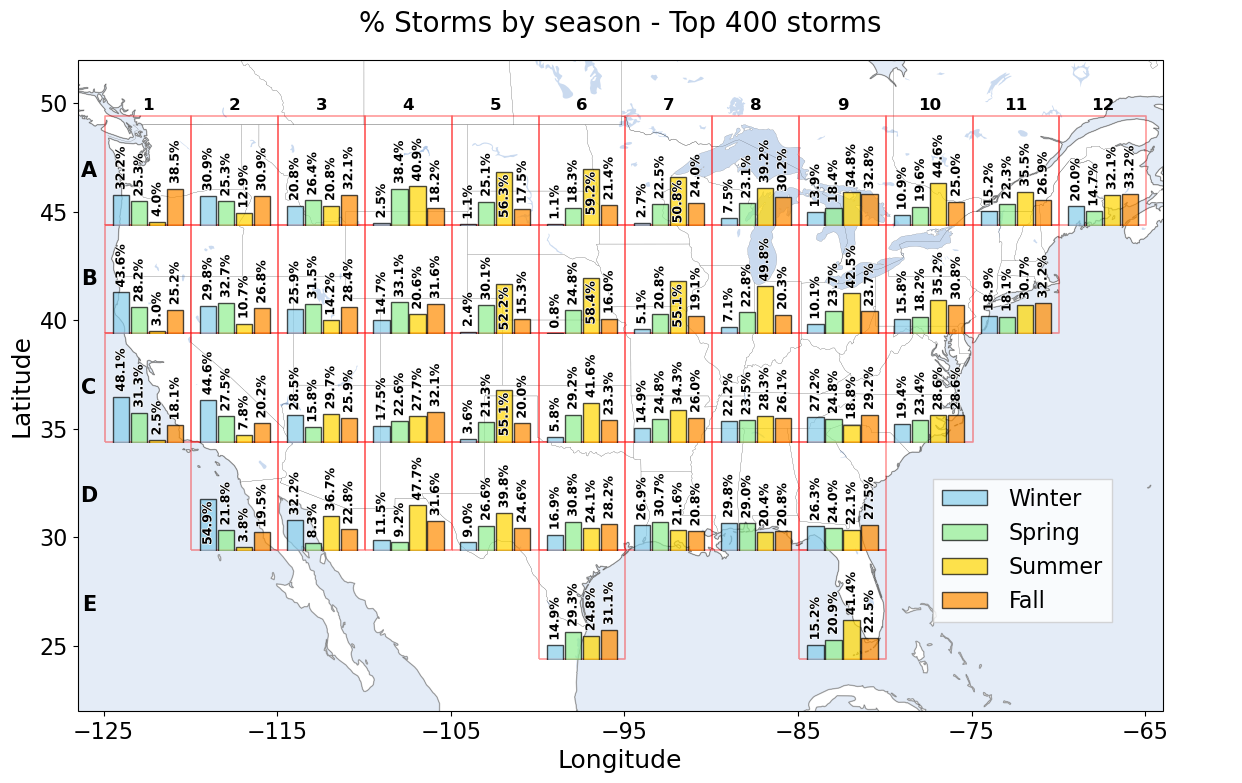

In [18]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 400
d_season = domain_season_func(top_storms=top_storms, filter_events=True, linear_trajectory_threshold=0.51)
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)
#d_season = domain_stats_func(top_storms=top_storms)

season_conus_plot(ax, d_season, f, domains, grid=grid, top_storms=top_storms)
# Add a legend for the barplot inset plots
inset_ax = plt.axes([0.65, 0.18, 0.30, 0.30], projection=ccrs.PlateCarree())
bar_plot_legend(inset_ax)

### % storms by seasons - linear trajectory - top 10

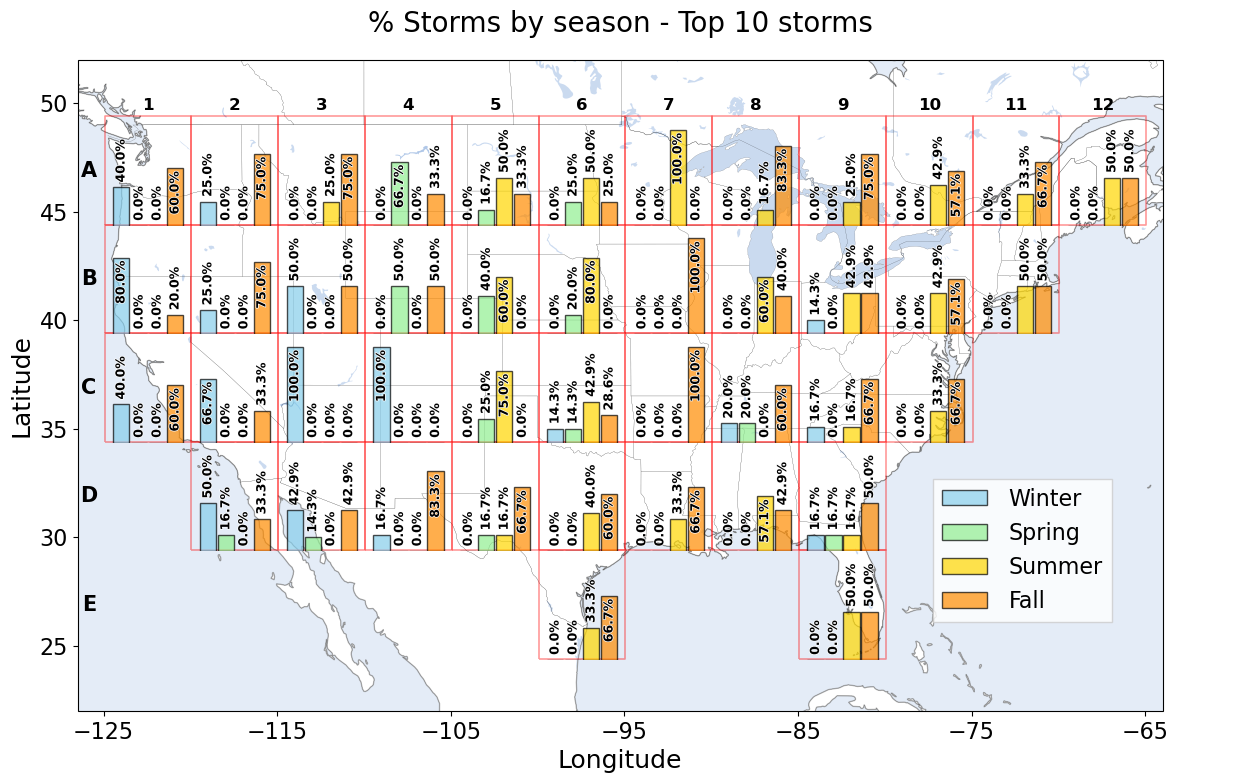

In [13]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 10
d_season = domain_season_func(top_storms=top_storms, filter_events=True, linear_trajectory_threshold=0.51)
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)
#d_season = domain_stats_func(top_storms=top_storms)

season_conus_plot(ax, d_season, f, domains, grid=grid, top_storms=top_storms)
# Add a legend for the barplot inset plots
inset_ax = plt.axes([0.65, 0.18, 0.30, 0.30], projection=ccrs.PlateCarree())
bar_plot_legend(inset_ax)

### % storms by seasons - linear trajectory - top 50

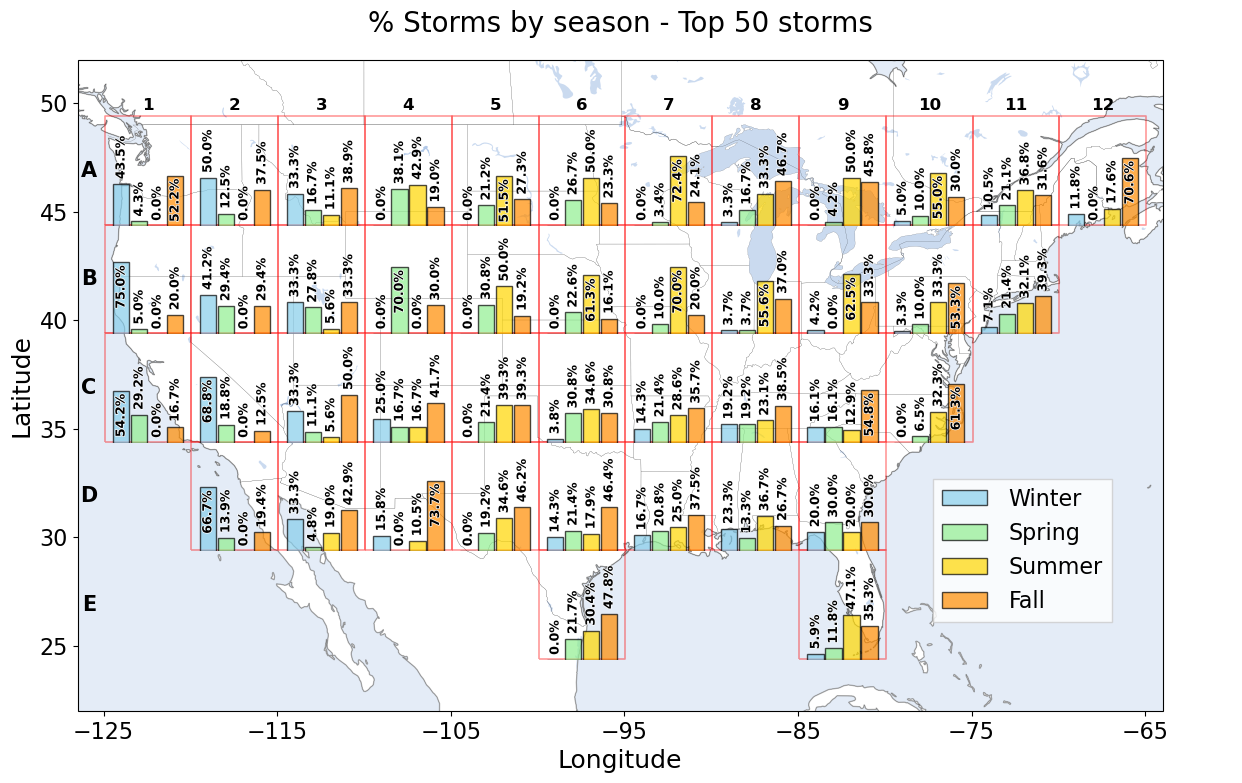

In [20]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 50
d_season = domain_season_func(top_storms=top_storms, filter_events=True, linear_trajectory_threshold=0.51)
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)
#d_season = domain_stats_func(top_storms=top_storms)

season_conus_plot(ax, d_season, f, domains, grid=grid, top_storms=top_storms)
# Add a legend for the barplot inset plots
inset_ax = plt.axes([0.65, 0.18, 0.30, 0.30], projection=ccrs.PlateCarree())
bar_plot_legend(inset_ax)

### % storms by seasons - linear trajectory - top 100

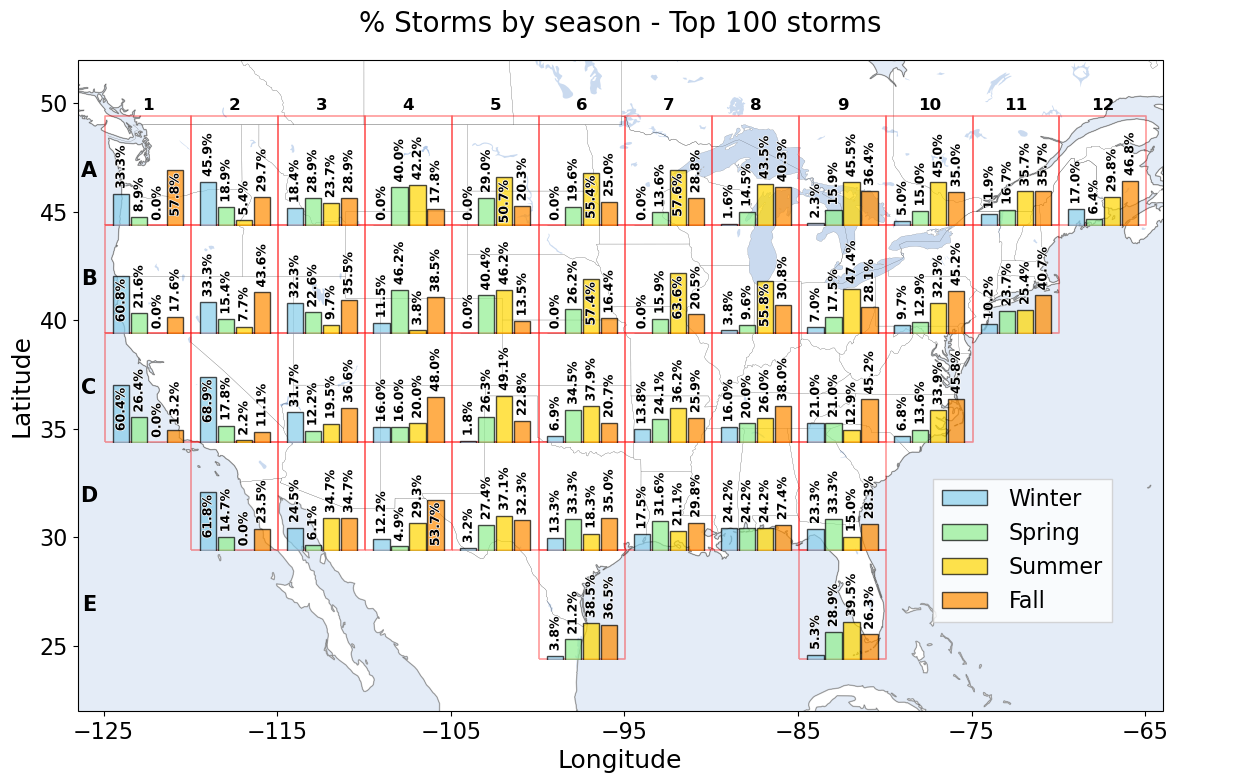

In [21]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 100
d_season = domain_season_func(top_storms=top_storms, filter_events=True, linear_trajectory_threshold=0.51)
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)
#d_season = domain_stats_func(top_storms=top_storms)

season_conus_plot(ax, d_season, f, domains, grid=grid, top_storms=top_storms)
# Add a legend for the barplot inset plots
inset_ax = plt.axes([0.65, 0.18, 0.30, 0.30], projection=ccrs.PlateCarree())
bar_plot_legend(inset_ax)

### % storms by seasons - all storms



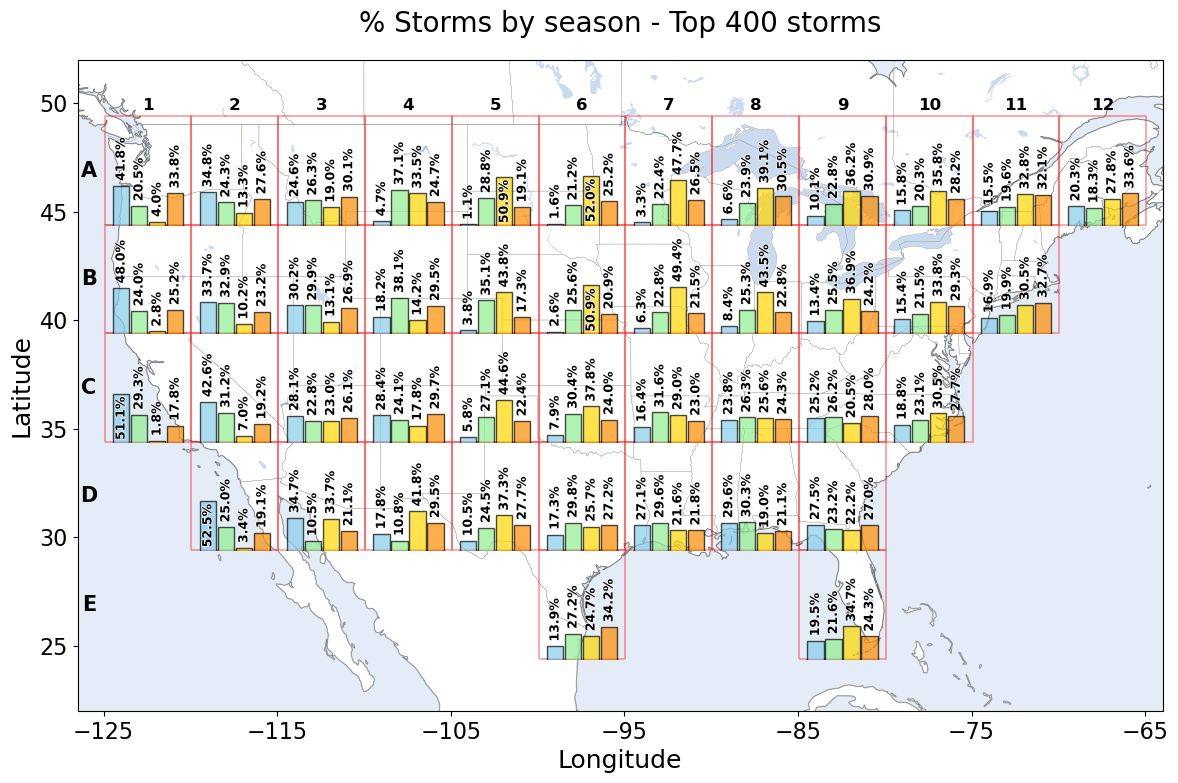

In [14]:
# plot without filtering by linear trajectory
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 400
d_season = domain_season_func(top_storms=top_storms, filter_events=False)
domain_stats_all = domain_stats_func(top_storms, filter_events=False)
season_conus_plot(ax, d_season, f, domains, grid=grid, top_storms=top_storms)